In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np
from matplotlib import pyplot
%matplotlib inline

# Sklearn — solo para split y métricas finales
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Detectar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

Dispositivo: cuda


In [4]:
# Parámetros del dataset
input_layer_size = 242
num_labels = 5

# Cargar y unir los 24 archivos
carpeta = "dataset"
nombres = [
    "S1-ADL1.csv",
    "S1-ADL2.dat", "S1-ADL3.dat", "S1-ADL4.dat", "S1-ADL5.dat",
    "S2-ADL1.dat", "S2-ADL2.dat", "S2-ADL3.dat", "S2-ADL4.dat", "S2-ADL5.dat",
    "S3-ADL1.dat", "S3-ADL2.dat", "S3-ADL3.dat", "S3-ADL4.dat", "S3-ADL5.dat",
    "S4-ADL1.dat", "S4-ADL2.dat", "S4-ADL3.dat", "S4-ADL4.dat", "S4-ADL5.dat",
    "S1-Drill.dat", "S2-Drill.dat", "S3-Drill.dat",
    "S4-Drill.csv"
]

dfs = []
for nombre in nombres:
    ruta = f"{carpeta}/{nombre}"
    df_temp = pd.read_csv(ruta, sep=' ', header=None)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

X = df.iloc[:, 1:243]
y = df.iloc[:, 244]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClases encontradas:\n{y.value_counts()}")

X shape: (869387, 242)
y shape: (869387,)

Clases encontradas:
244
0      338809
105    174278
103    138449
102     88113
104     85797
101     43941
Name: count, dtype: int64


In [5]:
# Unir X e y, eliminar filas sin etiqueta
df_clean = X.copy()
df_clean['y'] = y.values
df_clean = df_clean[df_clean['y'] != 0]

# Balancear clases
min_clase = df_clean['y'].value_counts().min()
df_balanceado = (
    df_clean
    .groupby('y', group_keys=False)
    .apply(lambda clase: clase.sample(n=min_clase, random_state=42))
    .reset_index(drop=True)
)

print(f"Distribución después de balancear:")
print(df_balanceado['y'].value_counts())
print(f"Total: {df_balanceado.shape[0]:,}")

# Separar X e y
X = df_balanceado.drop(columns=['y']).values
y = df_balanceado['y'].values

# Imputar NaN con la mediana
df_X = pd.DataFrame(X)
df_X = df_X.fillna(df_X.median())
X = df_X.values
print(f"\nNaN restantes: {pd.DataFrame(X).isna().sum().sum()}")

# Recodificar etiquetas 101-105 → 0-4
etiquetas = {101: 0, 102: 1, 103: 2, 104: 3, 105: 4}
y = np.array([etiquetas[val] for val in y])
print(f"\nClases recodificadas: {np.unique(y, return_counts=True)}")

# Split 80/20 — mismo que laboratorio anterior
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nEntrenamiento: {X_train.shape[0]:,}")
print(f"Prueba:        {X_test.shape[0]:,}")

# Normalización — mu y sigma calculados SOLO sobre train
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm  = (X_test - mu) / sigma

print(f"\nMedia X_train_norm (debe ser ~0): {X_train_norm.mean():.6f}")
print(f"Std X_train_norm  (debe ser ~1): {X_train_norm.std():.6f}")

C:\Users\HP\AppData\Local\Temp\ipykernel_23324\1324953628.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda clase: clase.sample(n=min_clase, random_state=42))


Distribución después de balancear:
y
101    43941
102    43941
103    43941
104    43941
105    43941
Name: count, dtype: int64
Total: 219,705

NaN restantes: 0

Clases recodificadas: (array([0, 1, 2, 3, 4]), array([43941, 43941, 43941, 43941, 43941]))

Entrenamiento: 175,764
Prueba:        43,941

Media X_train_norm (debe ser ~0): -0.000000
Std X_train_norm  (debe ser ~1): 1.000000


In [6]:
class OpportunityDataset(Dataset):
    """
    Dataset personalizado para el dataset Opportunity.
    Convierte los arrays de NumPy a tensores de PyTorch.
    """
    def __init__(self, X, y):
        # float32 → porque Linear espera ese tipo
        # long    → porque CrossEntropyLoss espera enteros de 64 bits
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        # cuántos ejemplos tiene el dataset
        return len(self.X)

    def __getitem__(self, idx):
        # cómo obtener UN ejemplo dado su índice
        return self.X[idx], self.y[idx]


# Crear datasets de train y test
train_dataset = OpportunityDataset(X_train_norm, y_train)
test_dataset  = OpportunityDataset(X_test_norm,  y_test)

# Crear dataloaders
dataloader = {
    'train': DataLoader(train_dataset, batch_size=256, shuffle=True,  pin_memory=True),
    'test':  DataLoader(test_dataset,  batch_size=256, shuffle=False, pin_memory=True)
}

print(f"Ejemplos de entrenamiento: {len(train_dataset):,}")
print(f"Ejemplos de prueba:        {len(test_dataset):,}")
print(f"Batches por época (train): {len(dataloader['train'])}")
print(f"Batches por época (test):  {len(dataloader['test'])}")

# Verificar forma de un batch
X_batch, y_batch = next(iter(dataloader['train']))
print(f"\nForma de un batch — X: {X_batch.shape}, y: {y_batch.shape}")

Ejemplos de entrenamiento: 175,764
Ejemplos de prueba:        43,941
Batches por época (train): 687
Batches por época (test):  172

Forma de un batch — X: torch.Size([256, 242]), y: torch.Size([256])


In [8]:
class OpportunityNet(nn.Module):
    """
    Red neuronal multicapa para clasificación de actividades.
    Reemplaza el modelo OneVsAll del laboratorio anterior.

    Arquitectura:
    Entrada (242) → 256 → 128 → 64 → Salida (5)
    """
    def __init__(self, n_inputs=242, n_outputs=5):
        super().__init__()

        self.red = nn.Sequential(
            # Capa 1: 242 → 256
            nn.Linear(n_inputs, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Capa 2: 256 → 128
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Capa 3: 128 → 64
            nn.Linear(128, 64),
            nn.ReLU(),

            # Capa de salida: 64 → 5 clases
            nn.Linear(64, n_outputs)
            # SIN Softmax — CrossEntropyLoss lo incluye internamente
        )

    def forward(self, x):
        return self.red(x)


# Instanciar y mover al dispositivo
model = OpportunityNet(n_inputs=242, n_outputs=5).to(device)

# Ver arquitectura completa
print(model)

# Contar parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

# Prueba rápida con el batch que obtuvimos antes
with torch.no_grad():
    salida = model(X_batch.to(device))
print(f"\nForma de la salida (logits): {salida.shape}")
print("→ [256 × 5] = correcto ✓")

OpportunityNet(
  (red): Sequential(
    (0): Linear(in_features=242, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=5, bias=True)
  )
)

Parámetros entrenables: 103,685

Forma de la salida (logits): torch.Size([256, 5])
→ [256 × 5] = correcto ✓


In [9]:
def fit(model, dataloader, epochs=30, checkpoint_path='./checkpoint.pt'):
    
    model.to(device)
    
    # Adam adapta el learning rate por peso automáticamente
    # lr=1e-3 es el valor estándar para Adam
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # CrossEntropyLoss incluye Softmax internamente
    # NO aplicar Softmax antes de pasarle los logits
    criterion = nn.CrossEntropyLoss()
    
    historial = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   []
    }
    
    mejor_val_acc = 0.0
    
    for epoch in range(1, epochs + 1):
        
        # ── ENTRENAMIENTO ──────────────────────────────
        model.train()
        train_loss, train_acc = [], []
        
        bar = tqdm(dataloader['train'])
        for X_batch, y_batch in bar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()       # 1. limpiar gradientes
            y_hat = model(X_batch)      # 2. forward
            loss = criterion(y_hat, y_batch)  # 3. calcular pérdida
            loss.backward()             # 4. backward
            optimizer.step()            # 5. actualizar pesos
            
            train_loss.append(loss.item())
            
            preds = torch.argmax(y_hat, axis=1)
            acc   = (preds == y_batch).sum().item() / len(y_batch)
            train_acc.append(acc)
            
            bar.set_description(
                f"Epoch {epoch}/{epochs} [train] "
                f"loss {np.mean(train_loss):.4f} acc {np.mean(train_acc):.4f}"
            )
        
        # ── EVALUACIÓN ─────────────────────────────────
        model.eval()
        val_loss, val_acc = [], []
        
        with torch.no_grad():
            bar = tqdm(dataloader['test'])
            for X_batch, y_batch in bar:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                y_hat = model(X_batch)
                loss  = criterion(y_hat, y_batch)
                
                val_loss.append(loss.item())
                
                preds = torch.argmax(y_hat, axis=1)
                acc   = (preds == y_batch).sum().item() / len(y_batch)
                val_acc.append(acc)
                
                bar.set_description(
                    f"Epoch {epoch}/{epochs} [val]  "
                    f"val_loss {np.mean(val_loss):.4f} val_acc {np.mean(val_acc):.4f}"
                )
        
        # Promediar métricas de la época
        epoch_train_loss = np.mean(train_loss)
        epoch_train_acc  = np.mean(train_acc)
        epoch_val_loss   = np.mean(val_loss)
        epoch_val_acc    = np.mean(val_acc)
        
        historial['train_loss'].append(epoch_train_loss)
        historial['train_acc'].append(epoch_train_acc)
        historial['val_loss'].append(epoch_val_loss)
        historial['val_acc'].append(epoch_val_acc)
        
        # ── CHECKPOINT ─────────────────────────────────
        # Guardar solo si mejoró val_acc respecto al mejor hasta ahora
        if epoch_val_acc > mejor_val_acc:
            mejor_val_acc = epoch_val_acc
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc':              epoch_val_acc,
                'val_loss':             epoch_val_loss,
            }, checkpoint_path)
            print(f"  ✓ Checkpoint guardado — epoch {epoch} val_acc {epoch_val_acc:.4f}")
        
        print(
            f"Epoch {epoch}/{epochs} | "
            f"loss {epoch_train_loss:.4f} | acc {epoch_train_acc:.4f} | "
            f"val_loss {epoch_val_loss:.4f} | val_acc {epoch_val_acc:.4f}"
        )
    
    print(f"\nMejor val_acc lograda: {mejor_val_acc:.4f}")
    return historial

In [10]:
# Instanciar modelo fresco
model = OpportunityNet(n_inputs=242, n_outputs=5).to(device)

# Entrenar — el mejor checkpoint se guarda automáticamente en ./checkpoint.pt
historial = fit(
    model,
    dataloader,
    epochs=30,
    checkpoint_path='./checkpoint.pt'
)

Epoch 1/30 [val]  val_loss 0.0973 val_acc 0.9770: 100%|██████████| 172/172 [00:01<00:00, 126.17it/s]


  ✓ Checkpoint guardado — epoch 1 val_acc 0.9770
Epoch 1/30 | loss 0.2655 | acc 0.9064 | val_loss 0.0973 | val_acc 0.9770


Epoch 2/30 [val]  val_loss 0.0677 val_acc 0.9905: 100%|██████████| 172/172 [00:00<00:00, 260.58it/s]


  ✓ Checkpoint guardado — epoch 2 val_acc 0.9905
Epoch 2/30 | loss 0.0828 | acc 0.9736 | val_loss 0.0677 | val_acc 0.9905


Epoch 3/30 [val]  val_loss 0.0516 val_acc 0.9940: 100%|██████████| 172/172 [00:00<00:00, 250.81it/s]


...

Epoch 28/30 | loss 0.0085 | acc 0.9974 | val_loss 0.0068 | val_acc 0.9984


Epoch 29/30 [train] loss 0.0083 acc 0.9973: 100%|██████████| 687/687 [00:03<00:00, 185.34it/s]
Epoch 29/30 [val]  val_loss 0.0060 val_acc 0.9985: 100%|██████████| 172/172 [00:00<00:00, 257.56it/s]


Epoch 29/30 | loss 0.0083 | acc 0.9973 | val_loss 0.0060 | val_acc 0.9985


Epoch 30/30 [train] loss 0.0087 acc 0.9973: 100%|██████████| 687/687 [00:03<00:00, 188.77it/s]
Epoch 30/30 [val]  val_loss 0.0059 val_acc 0.9987: 100%|██████████| 172/172 [00:00<00:00, 287.02it/s]


  ✓ Checkpoint guardado — epoch 30 val_acc 0.9987
Epoch 30/30 | loss 0.0087 | acc 0.9973 | val_loss 0.0059 | val_acc 0.9987

Mejor val_acc lograda: 0.9987


In [ ]:
# Cargar el mejor modelo guardado durante el entrenamiento
checkpoint = torch.load('checkpoint.pt', map_location=device, weights_only=False)

# Restaurar pesos en el modelo
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Checkpoint cargado:")
print(f"  Época:    {checkpoint['epoch']}")
print(f"  val_acc:  {checkpoint['val_acc']:.4f}")
print(f"  val_loss: {checkpoint['val_loss']:.4f}")

# Evaluación completa sobre test
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in dataloader['test']:
        X_batch = X_batch.to(device)
        y_hat   = model(X_batch)
        preds   = torch.argmax(y_hat, axis=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc_pytorch = accuracy_score(all_labels, all_preds) * 100
print(f"\nAccuracy final (test): {acc_pytorch:.2f}%")

# Reporte detallado por clase
nombres_clases = ['Relaxing', 'Coffee time', 'Early morning', 'Cleanup', 'Sandwich time']
print("\nReporte de clasificación:")
print(classification_report(all_labels, all_preds, target_names=nombres_clases))

Checkpoint cargado:
  Época:    30
  val_acc:  0.9987
  val_loss: 0.0059

Accuracy final (test): 99.87%

Reporte de clasificación:
               precision    recall  f1-score   support

     Relaxing       1.00      1.00      1.00      8786
  Coffee time       1.00      1.00      1.00      8662
Early morning       1.00      1.00      1.00      8865
      Cleanup       1.00      1.00      1.00      8819
Sandwich time       1.00      1.00      1.00      8809

     accuracy                           1.00     43941
    macro avg       1.00      1.00      1.00     43941
 weighted avg       1.00      1.00      1.00     43941



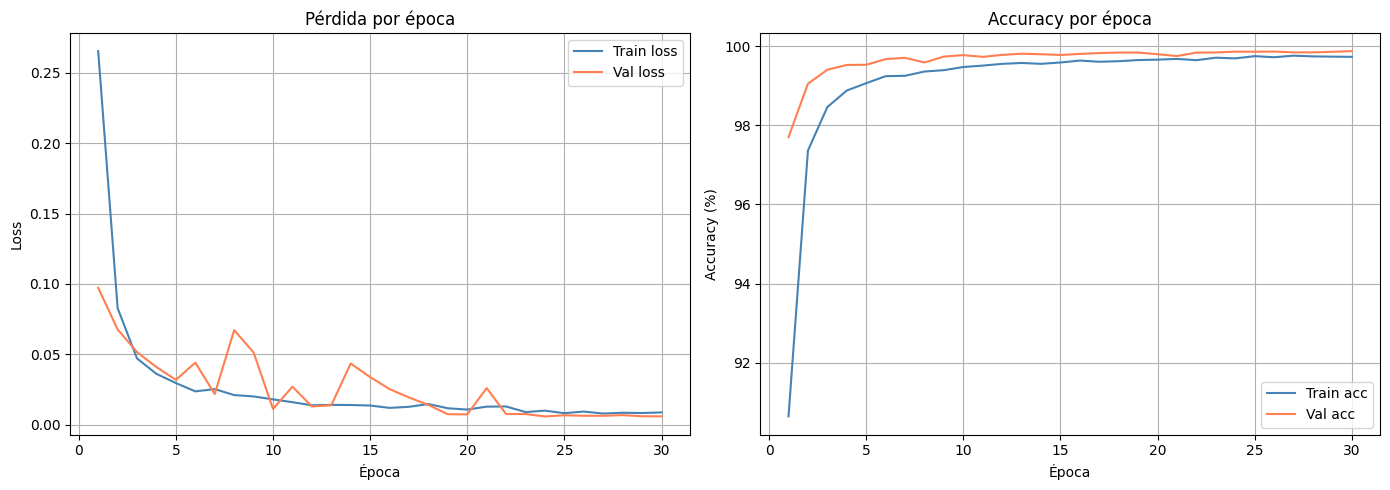

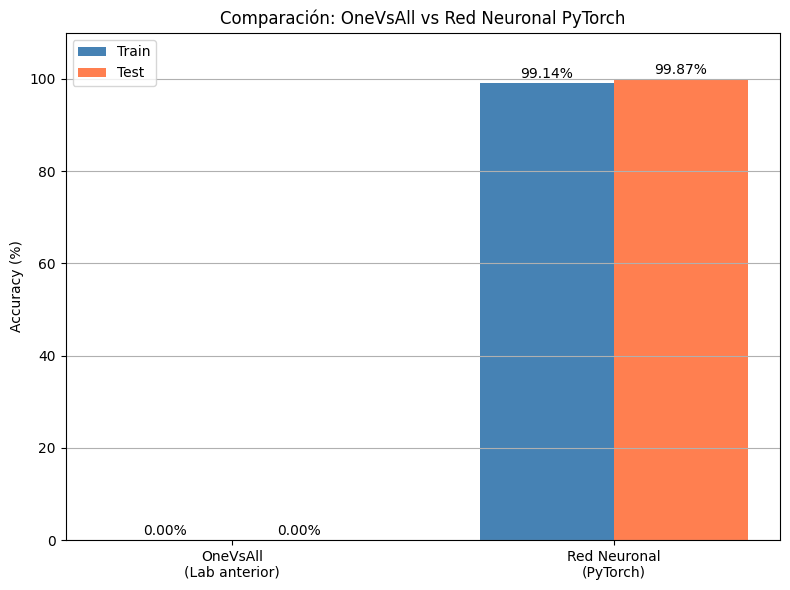

In [17]:
nombres_clases = ['Relaxing', 'Coffee time', 'Early morning', 'Cleanup', 'Sandwich time']

# ── Gráfica 1: Curvas de entrenamiento ──────────────────────
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(historial['train_loss']) + 1)

ax1.plot(epochs_range, historial['train_loss'], label='Train loss', color='steelblue')
ax1.plot(epochs_range, historial['val_loss'],   label='Val loss',   color='coral')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Pérdida por época')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, [a*100 for a in historial['train_acc']], label='Train acc', color='steelblue')
ax2.plot(epochs_range, [a*100 for a in historial['val_acc']],   label='Val acc',   color='coral')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy por época')
ax2.legend()
ax2.grid(True)

pyplot.tight_layout()
pyplot.show()

# ── Gráfica 2: Comparación con modelo anterior ──────────────
# Reemplaza estos valores con los de tu laboratorio anterior
acc_onevsall_train = 0.0   # <-- pega tu precisión de entrenamiento
acc_onevsall_test  = 0.0   # <-- pega tu precisión de prueba

acc_pytorch_train = np.mean(historial['train_acc']) * 100

modelos   = ['OneVsAll\n(Lab anterior)', 'Red Neuronal\n(PyTorch)']
acc_train = [acc_onevsall_train, acc_pytorch_train]
acc_test  = [acc_onevsall_test,  acc_pytorch]

x     = np.arange(len(modelos))
width = 0.35

fig, ax = pyplot.subplots(figsize=(8, 6))
barras_train = ax.bar(x - width/2, acc_train, width, label='Train', color='steelblue')
barras_test  = ax.bar(x + width/2, acc_test,  width, label='Test',  color='coral')

for barra in list(barras_train) + list(barras_test):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.5,
        f'{altura:.2f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparación: OneVsAll vs Red Neuronal PyTorch')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis='y')
pyplot.tight_layout()
pyplot.show()